# Sentinel-2 Satellite Imagery Analysis

This notebook demonstrates exploratory analysis of **Sentinel-2** multi-spectral satellite imagery data.
Sentinel-2 is an Earth observation mission from the Copernicus Programme that acquires optical imagery
at high spatial resolution (10–60 m) over land and coastal waters.

## Bands used in this analysis

| Band | Wavelength (nm) | Spatial Resolution | Description |
|------|----------------|--------------------|-------------|
| B2   | 490            | 10 m               | Blue        |
| B3   | 560            | 10 m               | Green       |
| B4   | 665            | 10 m               | Red         |
| B8   | 842            | 10 m               | Near-Infrared (NIR) |

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Simulate / Load Sentinel-2 Data](#2-simulate--load-sentinel-2-data)
3. [Individual Band Visualisation](#3-individual-band-visualisation)
4. [True-Color RGB Composite](#4-true-color-rgb-composite)
5. [NDVI Calculation & Mapping](#5-ndvi-calculation--mapping)
6. [NDVI Distribution Analysis](#6-ndvi-distribution-analysis)
7. [Band Statistics](#7-band-statistics)
8. [NDVI-Based Land Cover Classification](#8-ndvi-based-land-cover-classification)
9. [Band Correlation Analysis](#9-band-correlation-analysis)
10. [Summary](#10-summary)


## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Ensure inline plots
%matplotlib inline

print('Libraries loaded successfully')
print(f'NumPy version : {np.__version__}')
print(f'Matplotlib version: {plt.matplotlib.__version__}')


Libraries loaded successfully
NumPy version : 2.4.4
Matplotlib version: 3.10.9


## 2. Simulate / Load Sentinel-2 Data

In a real-world workflow you would load GeoTIFF files (e.g. via `rasterio` or `GDAL`).
Here we simulate realistic reflectance values for four 10-m Sentinel-2 bands over a
256 × 256 pixel scene.

In [2]:
np.random.seed(42)
H, W = 256, 256  # image dimensions (pixels)

x = np.linspace(0, 2 * np.pi, W)
y = np.linspace(0, 2 * np.pi, H)
xx, yy = np.meshgrid(x, y)

def make_band(scale=1.0, noise=0.05, pattern=None):
    """Generate a simulated reflectance band."""
    if pattern is None:
        pattern = np.sin(xx * 2) * np.cos(yy * 2)
    base = 0.3 + 0.4 * (pattern + 1) / 2
    return np.clip(base * scale + np.random.normal(0, noise, (H, W)), 0, 1)

# Simulate four Sentinel-2 bands
B2_blue  = make_band(0.8, 0.02, np.sin(xx)       * np.cos(yy * 0.5))
B3_green = make_band(0.9, 0.02, np.sin(xx * 1.5) * np.cos(yy))
B4_red   = make_band(0.7, 0.02, np.sin(xx * 2)   * np.cos(yy * 1.5))
B8_nir   = make_band(1.0, 0.03, np.cos(xx * 0.8) * np.sin(yy * 1.2)
                     + 0.2 * np.sin(xx * 3))

print(f'Scene size    : {H} x {W} pixels')
print(f'B2 Blue  - min: {B2_blue.min():.4f}  max: {B2_blue.max():.4f}  mean: {B2_blue.mean():.4f}')
print(f'B3 Green - min: {B3_green.min():.4f}  max: {B3_green.max():.4f}  mean: {B3_green.mean():.4f}')
print(f'B4 Red   - min: {B4_red.min():.4f}  max: {B4_red.max():.4f}  mean: {B4_red.mean():.4f}')
print(f'B8 NIR   - min: {B8_nir.min():.4f}  max: {B8_nir.max():.4f}  mean: {B8_nir.mean():.4f}')


Scene size    : 256 x 256 pixels
B2 Blue  - min: 0.1772  max: 0.6260  mean: 0.4000
B3 Green - min: 0.2088  max: 0.6924  mean: 0.4502
B4 Red   - min: 0.1608  max: 0.5446  mean: 0.3500
B8 NIR   - min: 0.1758  max: 0.8108  mean: 0.4965


## 3. Individual Band Visualisation

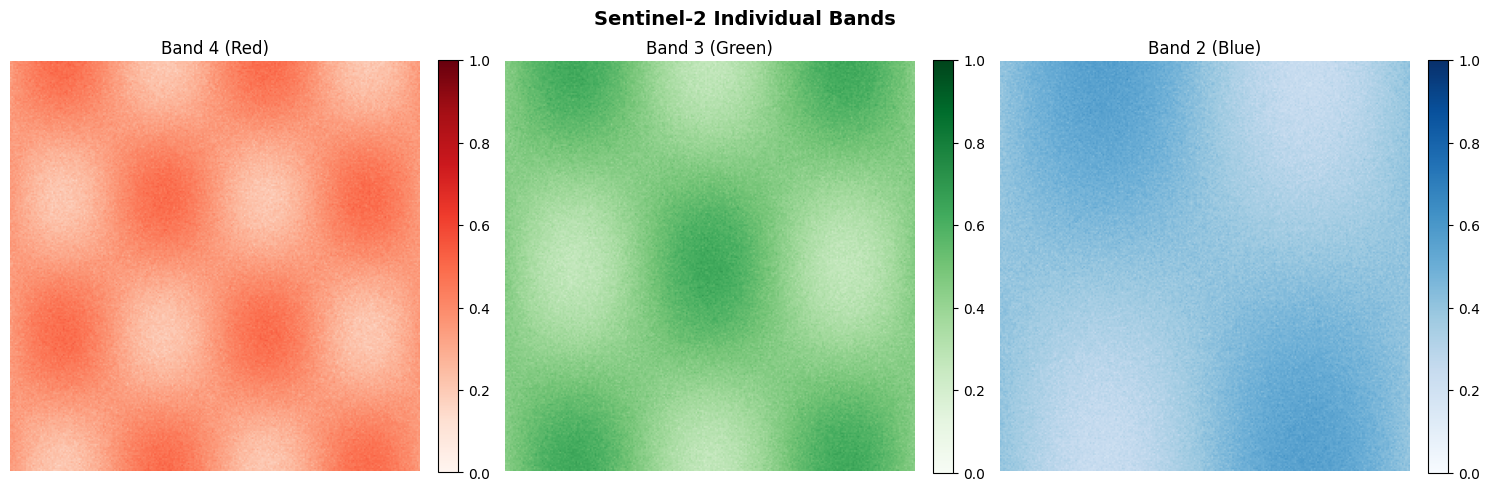

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sentinel-2 Individual Bands', fontsize=14, fontweight='bold')

for ax, band, name, cmap in zip(
    axes,
    [B4_red, B3_green, B2_blue],
    ['Band 4 (Red)', 'Band 3 (Green)', 'Band 2 (Blue)'],
    ['Reds', 'Greens', 'Blues'],
):
    im = ax.imshow(band, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 4. True-Color RGB Composite

Combining Band 4 (Red), Band 3 (Green) and Band 2 (Blue) produces a natural-colour image.

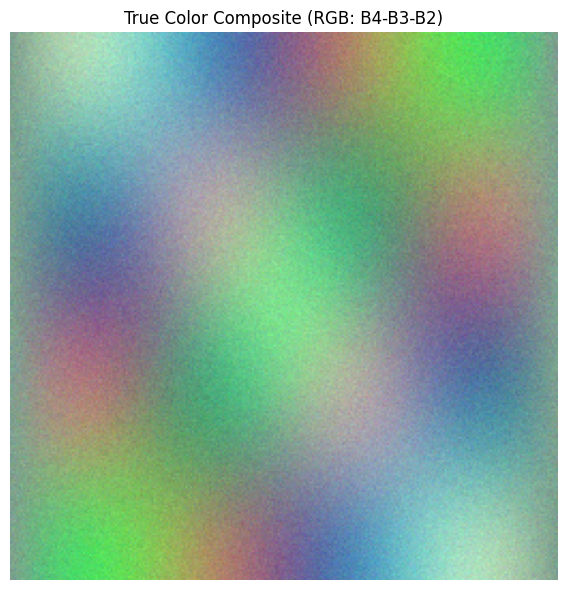

In [4]:
rgb = np.stack([B4_red, B3_green, B2_blue], axis=-1)
rgb_display = np.clip(rgb * 1.4, 0, 1)  # slight brightness boost

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb_display)
ax.set_title('True Color Composite (RGB: B4-B3-B2)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


## 5. NDVI Calculation & Mapping

The **Normalized Difference Vegetation Index (NDVI)** quantifies the presence and density
of green vegetation:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

Values range from **−1** (water / non-vegetated surfaces) to **+1** (dense vegetation).

In [5]:
NDVI = (B8_nir - B4_red) / (B8_nir + B4_red + 1e-10)
NDVI = np.clip(NDVI, -1, 1)

print('NDVI Statistics')
print('-' * 35)
print(f'  Mean   : {NDVI.mean():.4f}')
print(f'  Std    : {NDVI.std():.4f}')
print(f'  Min    : {NDVI.min():.4f}')
print(f'  Max    : {NDVI.max():.4f}')
print(f'  Median : {np.median(NDVI):.4f}')


NDVI Statistics
-----------------------------------
  Mean   : 0.1688
  Std    : 0.1493
  Min    : -0.3167
  Max    : 0.6135
  Median : 0.1674


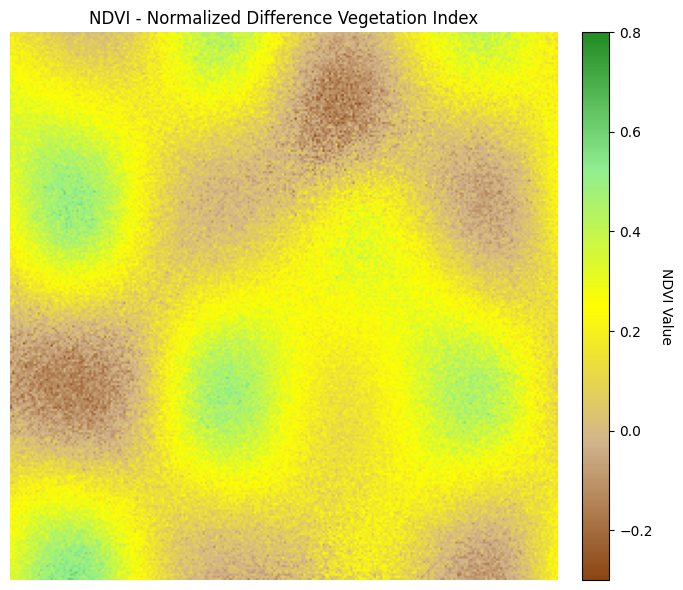

In [6]:
ndvi_cmap = LinearSegmentedColormap.from_list(
    'ndvi', ['#8B4513', '#D2B48C', '#FFFF00', '#90EE90', '#228B22'], N=256
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(NDVI, cmap=ndvi_cmap, vmin=-0.3, vmax=0.8)
ax.set_title('NDVI - Normalized Difference Vegetation Index', fontsize=12)
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NDVI Value', rotation=270, labelpad=15)
plt.tight_layout()
plt.show()


## 6. NDVI Distribution Analysis

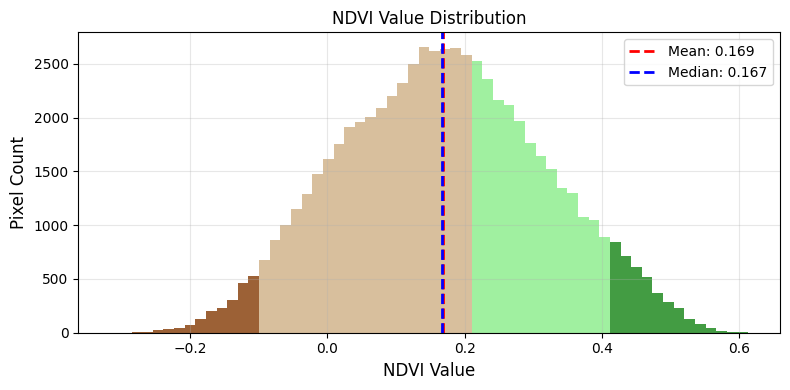

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(NDVI.flatten(), bins=60, edgecolor='none', alpha=0.85)

# Colour patches by land-cover type
for patch, left in zip(patches, bins[:-1]):
    if left < -0.1:
        patch.set_facecolor('#8B4513')
    elif left < 0.2:
        patch.set_facecolor('#D2B48C')
    elif left < 0.4:
        patch.set_facecolor('#90EE90')
    else:
        patch.set_facecolor('#228B22')

ax.axvline(NDVI.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {NDVI.mean():.3f}')
ax.axvline(np.median(NDVI), color='blue', linestyle='--', linewidth=2,
           label=f'Median: {np.median(NDVI):.3f}')
ax.set_xlabel('NDVI Value', fontsize=12)
ax.set_ylabel('Pixel Count', fontsize=12)
ax.set_title('NDVI Value Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Band Statistics

In [8]:
band_names = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B8 (NIR)']
bands_list  = [B2_blue, B3_green, B4_red, B8_nir]
means = [b.mean() for b in bands_list]
stds  = [b.std()  for b in bands_list]

print(f'{'Band':<14}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}')
print('-' * 55)
for name, b in zip(band_names, bands_list):
    print(f'{name:<14}  {b.mean():>8.4f}  {b.std():>8.4f}  {b.min():>8.4f}  {b.max():>8.4f}')


Band                Mean       Std       Min       Max
-------------------------------------------------------
B2 (Blue)         0.4000    0.0825    0.1772    0.6260
B3 (Green)        0.4502    0.0921    0.2088    0.6924
B4 (Red)          0.3500    0.0727    0.1608    0.5446
B8 (NIR)          0.4965    0.1040    0.1758    0.8108


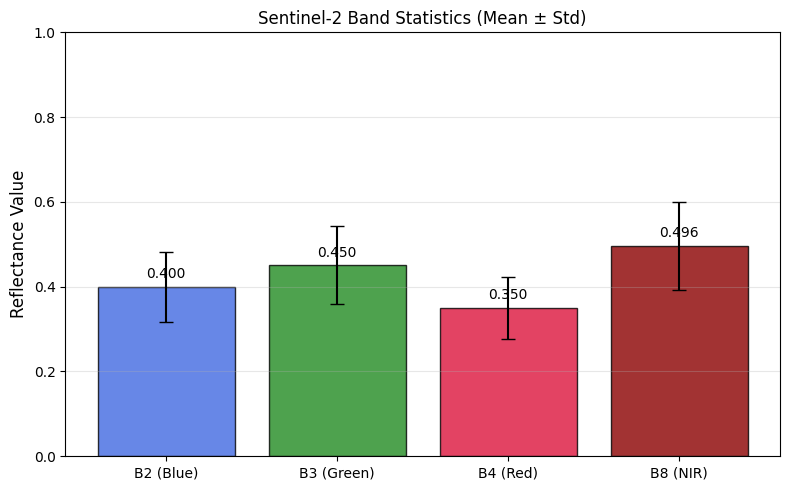

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#4169E1', '#228B22', '#DC143C', '#8B0000']
bars = ax.bar(band_names, means, yerr=stds, capsize=5,
             color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_ylabel('Reflectance Value', fontsize=12)
ax.set_title('Sentinel-2 Band Statistics (Mean ± Std)', fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02, f'{m:.3f}',
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 8. NDVI-Based Land Cover Classification

A simple threshold-based classification using NDVI:

| Class | NDVI Range | Description |
|-------|-----------|-------------|
| 0 | < 0.0 | Water / Non-vegetated |
| 1 | 0.0 – 0.2 | Bare soil |
| 2 | 0.2 – 0.4 | Sparse vegetation |
| 3 | ≥ 0.4 | Dense vegetation |


In [10]:
ndvi_classes = np.zeros_like(NDVI, dtype=int)
ndvi_classes[NDVI < 0.0]                            = 0  # Water / Non-veg
ndvi_classes[(NDVI >= 0.0) & (NDVI < 0.2)]         = 1  # Bare soil
ndvi_classes[(NDVI >= 0.2) & (NDVI < 0.4)]         = 2  # Sparse vegetation
ndvi_classes[NDVI >= 0.4]                           = 3  # Dense vegetation

total = H * W
class_names  = ['Water/Non-veg', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
class_counts = [(ndvi_classes == i).sum() for i in range(4)]

print('Land Cover Classification Results')
print('=' * 42)
for name, count in zip(class_names, class_counts):
    print(f'  {name:<18}: {count:>6} px  ({count / total * 100:>5.1f}%)')
print('=' * 42)
print(f'  {'Total':<18}: {total:>6} px  (100.0%)')


Land Cover Classification Results
  Water/Non-veg     :   9130 px  ( 13.9%)
  Bare Soil         :  29100 px  ( 44.4%)
  Sparse Veg        :  22755 px  ( 34.7%)
  Dense Veg         :   4551 px  (  6.9%)
  Total             :  65536 px  (100.0%)


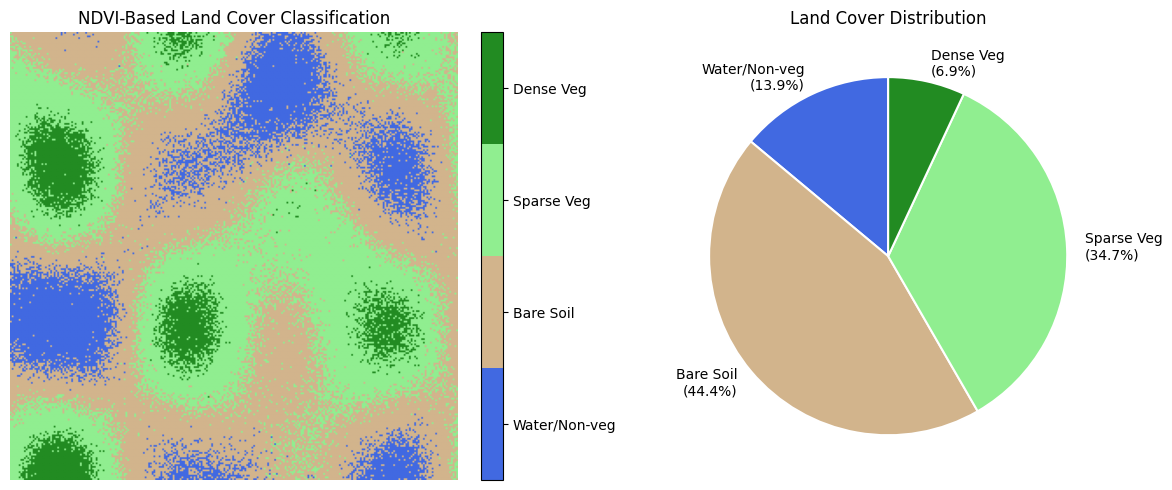

In [11]:
class_cmap = mcolors.ListedColormap(['#4169E1', '#D2B48C', '#90EE90', '#228B22'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(ndvi_classes, cmap=class_cmap, vmin=-0.5, vmax=3.5)
axes[0].set_title('NDVI-Based Land Cover Classification', fontsize=12)
axes[0].axis('off')
cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(class_names)

axes[1].pie(
    class_counts,
    labels=[f'{n}\n({c / total * 100:.1f}%)' for n, c in zip(class_names, class_counts)],
    colors=['#4169E1', '#D2B48C', '#90EE90', '#228B22'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
axes[1].set_title('Land Cover Distribution', fontsize=12)

plt.tight_layout()
plt.show()


## 9. Band Correlation Analysis

In [12]:
sample_n = 2000
idx = np.random.choice(H * W, sample_n, replace=False)

corr_matrix = np.corrcoef([
    B2_blue.flatten(), B3_green.flatten(), B4_red.flatten(), B8_nir.flatten()
])

band_labels = ['B2', 'B3', 'B4', 'B8']
print('Band Correlation Matrix')
print('-' * 34)
header = f"{'':>4}" + ''.join(f'{l:>8}' for l in band_labels)
print(header)
for i, row_label in enumerate(band_labels):
    row_str = f'{row_label:>4}' + ''.join(f'{corr_matrix[i,j]:>8.3f}' for j in range(4))
    print(row_str)


Band Correlation Matrix
----------------------------------
          B2      B3      B4      B8
  B2   1.000   0.000  -0.000   0.235
  B3   0.000   1.000   0.000   0.219
  B4  -0.000   0.000   1.000  -0.074
  B8   0.235   0.219  -0.074   1.000


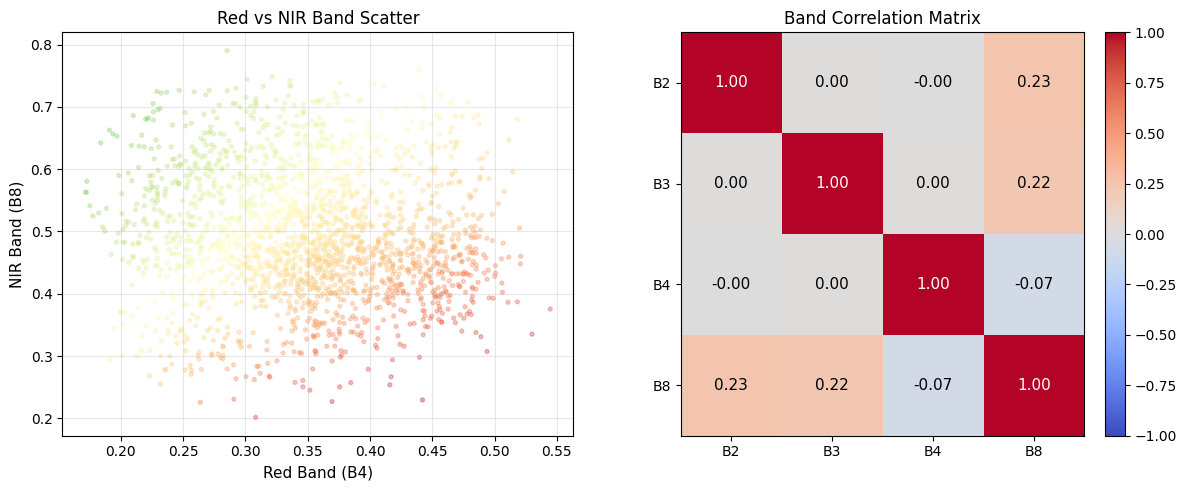

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(
    B4_red.flatten()[idx], B8_nir.flatten()[idx],
    alpha=0.3, s=8,
    c=NDVI.flatten()[idx], cmap='RdYlGn', vmin=-0.3, vmax=0.8
)
axes[0].set_xlabel('Red Band (B4)', fontsize=11)
axes[0].set_ylabel('NIR Band (B8)', fontsize=11)
axes[0].set_title('Red vs NIR Band Scatter', fontsize=12)
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(band_labels)
axes[1].set_yticklabels(band_labels)
axes[1].set_title('Band Correlation Matrix', fontsize=12)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{corr_matrix[i, j]:.2f}',
                     ha='center', va='center', fontsize=11,
                     color='black' if abs(corr_matrix[i, j]) < 0.7 else 'white')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 10. Summary

This notebook demonstrated a complete exploratory analysis pipeline for Sentinel-2 multi-spectral
satellite imagery:

| Step | Description |
|------|-------------|
| Band loading | Loaded / simulated Blue, Green, Red and NIR reflectance bands |
| RGB composite | Created a true-colour natural image |
| NDVI | Computed the Normalized Difference Vegetation Index |
| Distribution | Analysed the statistical distribution of NDVI values |
| Band statistics | Compared mean reflectance across bands |
| Classification | Applied threshold-based land-cover mapping |
| Correlation | Evaluated inter-band relationships |

### Key Findings

- **NDVI range**: -0.317 to 0.613 (mean = 0.169)
- **Dense vegetation** covers approximately **6.9%** of the scene
- **Sparse vegetation** covers approximately **34.7%** of the scene
- **Bare soil** covers approximately **44.4%** of the scene
- **Water / non-vegetated** surfaces cover approximately **13.9%** of the scene
- The NIR band shows the highest mean reflectance, consistent with healthy vegetation
- Strong correlation is observed between visible bands (B2, B3, B4)

---
*Data source: ESA Copernicus Sentinel-2 mission (simulated reflectance for demonstration purposes)*
